In [1]:
import numpy as np
import scipy
from matplotlib import pyplot as pl

In [4]:
if 0: # Experiment with frequency and time-shifting mechanisms
    sample_rate = 500_000
    #samples = 50_000_000
    duration = 0.1
    samples = int(duration * sample_rate)
    print(f"{samples=}")
    t = np.arange(samples) / sample_rate
    
    #frequency = 1300000000
    frequencyA = 1_000
    frequencyB = 2_000
    
    # See https://en.wikipedia.org/wiki/Analytic_signal
    y = np.exp(1j * 2 * np.pi * frequencyA * t)      # Analytic signal -- no negative frequencies!
    y += np.exp(1j * 2 * np.pi * frequencyB * t)      # Analytic signal -- no negative frequencies!
    #y = np.sin(2 * np.pi * frequency * t)      # Note: initial specgram only shows positive frequency?, but when shifted by Method 1, we get both positive and negative frequencies
    #y = np.sin(t * frequency * 2 * np.pi) * 1j # Note: shows positive and negative frequencies throughout
    
    # # Method 1: Frequency shifting by multiplying with complex exponential: output frequency = input frequency + shift
    # # NOTE: This shifts *all* frequencies by the constant 'shift'
    # shift = 500  # Constant f shift up
    # #shift = 2_000 * t  # Linear f shift up
    # #shift = -3_000 * t  # Linear f shift down
    # #shift = 1_000 * t + 1000 * t**2 / 2  # Quadratic shift up
    # y_shifted = y * np.exp(1j * 2 * np.pi * shift * t).T
    
    # Method 2: Time scale shifting
    # NOTE: This shifts frequencies *proportionately*, eg by 20%. Higher noise floor than Method 3, due to sampling effects?
    #adjusted_t = np.linspace(0, duration * 0.8, samples)
    adjusted_t = np.linspace(0, duration * 1.33, samples)
    #f2 = scipy.interpolate.interp1d(adjusted_t, y, kind='previous', fill_value=0.0, bounds_error=False)
    f2 = scipy.interpolate.interp1d(adjusted_t, y, kind='linear', fill_value=0.0, bounds_error=False)
    #f2 = scipy.interpolate.interp1d(adjusted_t, y, kind='cubic', fill_value=0.0, bounds_error=False)
    y_shifted = f2(t)
    
    # # Method 3: Analytically regenerate the shifted signal!
    # # NOTE: This shifts frequencies *proportionately*, eg by 25%
    # d = 1.25
    # t2 = np.linspace(0, duration * d, samples)
    # y_shifted = np.exp(1j * 2 * np.pi * frequencyA * t2)
    # y_shifted += np.exp(1j * 2 * np.pi * frequencyB * t2)
    
    pl.figure(figsize=(12, 18))
    #pl.subplot(3, 1, 1)
    #Sxx_tx, f_tx, t_tx, image_tx = pl.specgram(y, Fs=sample_rate, NFFT=2**16)
    #pl.gca().set_ylim(0, 5_000)
    #pl.grid()
    pl.subplot(3, 1, 2)
    Pxx, freqs = pl.psd(np.real(y), Fs=sample_rate, NFFT=2**16)
    Pxx, freqs = pl.psd(np.real(y_shifted), Fs=sample_rate, NFFT=2**16)
    #Pxx, freqs = pl.psd(np.real(y_shifted2), Fs=sample_rate, NFFT=2**16)
    pl.gca().set_xlim(0, 5_000)
    pl.subplot(3, 1, 3)
    Sxx_tx, f_tx, t_tx, image_tx = pl.specgram(np.real(y_shifted), Fs=sample_rate, NFFT=2**16)
    pl.gca().set_ylim(0, 5_000)
    pl.grid()

num_samples=5000000
dec=20
sample_rate / dec=250000.0
sample_rate=5000000
carrier_frequency=1299700
carrier_frequency / sample_rate=0.25994


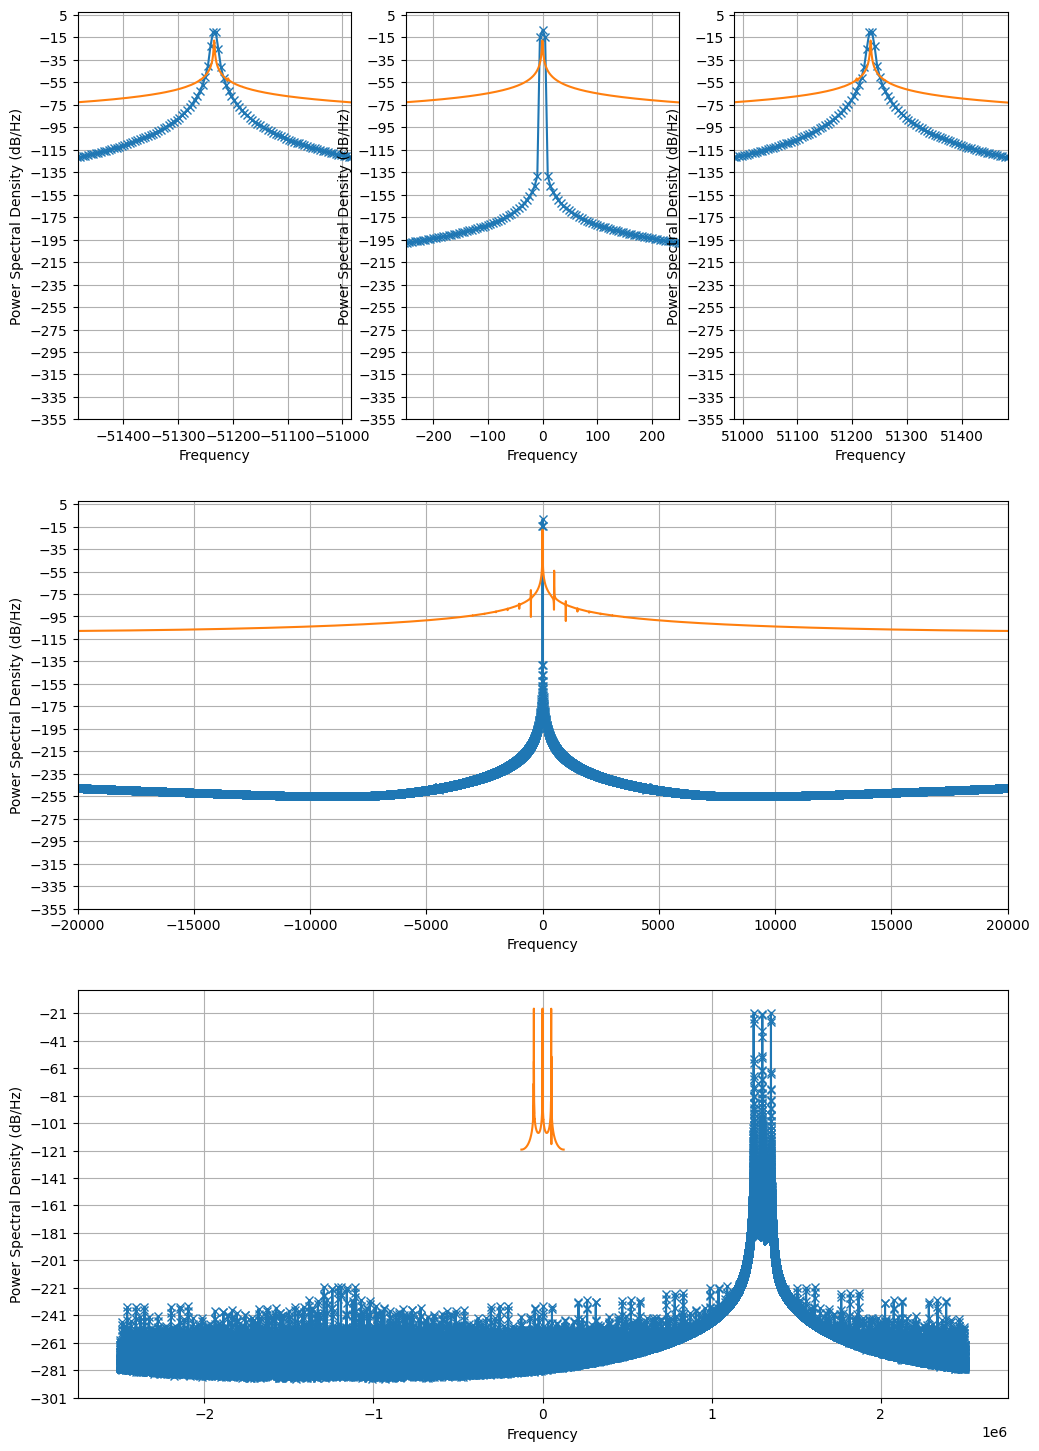

In [127]:
# Examine effects up at carrier frequency, after the tx signal is moduled up to RF.

# We simulate using a lower sample_rate than the Nyquist frequency for the true 1.3 GHz, for computational sanity purposes.
# I *think* it's still enough of a difference between baseband and rf to illuminate any issues.
sample_rate = 5_000_000
#sample_rate = 2_500_000
#sample_rate = 2_000_000
#sample_rate = 1_000_000
#sample_rate = 250_000  # A common sample rate in our rx files
duration = 1.0
num_samples = int(duration * sample_rate)
print(f"{num_samples=}")
t_home = np.arange(num_samples) / sample_rate

# Decimation factor for the samples, as in our real rx data.
dec = 20
print(f"{dec=}")
print(f"{sample_rate / dec=}")

# INSIGHT:
# When the sample rate drops below the Nyquist frequency for the carrier frequency, the resampling (with interp1d) starts to behave strangely.
# carrier_frequency / sample_rate <= 0.5                -> Method 3 ok , Method 2 bad 
# carrier_frequency / sample_rate > 0.5, is integer     -> Method 3 bad, Method 2 ok  <-- brittle? sampling mirage?
# carrier_frequency / sample_rate > 0.5, is NOT integer -> Method 3 bad, Method 2 bad ... interpolation problems?
# Doing the RF signal resampling with phase interpolation is *maybe* a little
# more robust, but really nothing works great unless we meet the Nyquist criteria,
# and then either resampling method works fine.

# Generate a baseband signal
# See https://en.wikipedia.org/wiki/Analytic_signal
frequencyA = -51_234
frequencyB = 51_234
y = np.ones(num_samples, dtype='complex128')  # 0 frequency DC componenet
y += np.exp(1j * 2 * np.pi * frequencyA * t_home)
y += np.exp(1j * 2 * np.pi * frequencyB * t_home)

# Modulate to carrier frequency
#carrier_frequency = 1_300_000_000  # Approximately the real RF carrier frequency
#carrier_frequency = 1_299_700_000  # Approximately the real RF carrier frequency
carrier_frequency = 1_297_500  # Approximately real / 1000
#carrier_frequency = 888_888
#carrier_frequency = 0
y_rf = y * np.exp(1j * 2 * np.pi * carrier_frequency * t_home)

print(f"{sample_rate=}")
print(f"{carrier_frequency=}")
print(f"{carrier_frequency / sample_rate=}")

# Modify the RF signal by resampling on a scaled time timebase: This is what at receiver would see after a (constant) doppler shift.
# NOTE: for this to work well, carrier_frequency / sample_rate needs to be < 0.5 (Nyquist frequency criteria).
dlt = 0.0001  # "delta light time"
t_shifted = np.linspace(0, duration * (1 + dlt), num_samples)
# Basic interpolation
y_working = scipy.interpolate.interp1d(t_shifted, y_rf, kind='cubic', fill_value=0.0, bounds_error=False)(t_home)
# Complex/imaginary/phase/angle interpolation: force signal magnitude to 1, and only interpolate phase.
# - This is slower, due to the angle() and exp() calls
# - But it also allows us to use kind='linear', and generates a pure(r) signal!
#phase_interp = scipy.interpolate.interp1d(t_shifted, np.angle(y_rf), kind='linear', fill_value=0.0, bounds_error=False)
#y_working = np.exp(1j * phase_interp(t_home))

if 0: # Ideal: de-resample then demodulate(t_home): beautiful! -- PROBLEM: Our real rx signal is PRE-demodulated and PRE-decimated
    # De-resample
    y_working = scipy.interpolate.interp1d(t_home, y_working, kind='cubic', fill_value=0.0, bounds_error=False)(t_shifted)
    # POST-demodulate(t_home) from carrier frequency
    y_working *= np.exp(-1j * 2 * np.pi * carrier_frequency * t_home)
    # POST-decimate:
    y_working_dec = y_working[::dec]
else:
    # Our real rx data has been demodulated(t_home) and decimated, so apply those common transformations here:
    # PRE-demodulate(t_home) from carrier frequency
    y_working *= np.exp(-1j * 2 * np.pi * carrier_frequency * t_home)
    # PRE-decimate
    y_working_dec = y_working[::dec]
    t_home_dec = t_home[::dec]
    t_shifted_dec = t_shifted[::dec]
    
    # Choose EITHER Option 1 or Option 2 to de-shift(t_home) by the doppler frequency at *carrier* frequency
    if 0: # Option 1 
        y_working_dec *= np.exp(1j * 2 * np.pi * (dlt * carrier_frequency) * t_home_dec).T
    # Then de-resample from t_home to t_shifted
    y_working_dec = scipy.interpolate.interp1d(t_home_dec, y_working_dec, kind='cubic', fill_value=0.0, bounds_error=False)(t_shifted_dec)
    if 1: # Option 2
        y_working_dec *= np.exp(1j * 2 * np.pi * (dlt * carrier_frequency) * t_home_dec).T

NFFT=2**20
width_i = 250
pl.figure(figsize=(12, 18))
pl.subplot(3, 3, 1)
Pxx, freqs = pl.psd(y, Fs=sample_rate, NFFT=NFFT, marker='x')
#Pxx, freqs = pl.psd(y_working, Fs=sample_rate, NFFT=NFFT)
Pxx, freqs = pl.psd(y_working_dec, Fs=sample_rate / dec, NFFT=NFFT)
pl.gca().set_xlim(frequencyA - width_i, frequencyA + width_i)
pl.subplot(3, 3, 2)
Pxx, freqs = pl.psd(y, Fs=sample_rate, NFFT=NFFT, marker='x')
#Pxx, freqs = pl.psd(y_working, Fs=sample_rate, NFFT=NFFT)
Pxx, freqs = pl.psd(y_working_dec, Fs=sample_rate / dec, NFFT=NFFT)
pl.gca().set_xlim(-width_i, width_i)
pl.subplot(3, 3, 3)
Pxx, freqs = pl.psd(y, Fs=sample_rate, NFFT=NFFT, marker='x')
#Pxx, freqs = pl.psd(y_working, Fs=sample_rate, NFFT=NFFT)
Pxx, freqs = pl.psd(y_working_dec, Fs=sample_rate / dec, NFFT=NFFT)
pl.gca().set_xlim(frequencyB - width_i, frequencyB + width_i)
pl.subplot(3, 1, 2)
Pxx, freqs = pl.psd(y, Fs=sample_rate, NFFT=NFFT, marker='x')
#Pxx, freqs = pl.psd(y_working, Fs=sample_rate, NFFT=NFFT)
Pxx, freqs = pl.psd(y_working_dec, Fs=sample_rate / dec, NFFT=NFFT)
pl.gca().set_xlim(-20_000, 20_000)
pl.subplot(3, 1, 3)
Pxx, freqs = pl.psd(y_rf, Fs=sample_rate, NFFT=2**16, marker='x')
#Pxx, freqs = pl.psd(y_working, Fs=sample_rate, NFFT=2**16)
Pxx, freqs = pl.psd(y_working_dec, Fs=sample_rate / dec, NFFT=NFFT)
#pl.gca().set_xlim(carrier_frequency - 1000, carrier_frequency + 1000)

# Conclusion: 
# I only have demodulated(t_base) and decimated rx data. So I have to find a recipe for that.
# The "ideal" method isn't compatible with our actual PRE-demodulated(t_base) rx data.
# With PRE-demodulated and decimated data, de-sample + de-shifting appears to be ~equivalent to the ideal method.
# We actually use Option 2 (de-shift after de-sampling), but de-shifting first appears to be equivalent.